# Lab04 Python Data Science with Pandas

## Please submit your finished lab04 jupyter notebook via pull request in GitHub

In [1]:
# magic command to display matplotlib plots inline within the ipython notebook webpage
%matplotlib inline

# import necessary modules
import pandas as pd, numpy as np, matplotlib.pyplot as plt

## Part 1 <br /> Basics of Selecting and Slicing Data

In [3]:
# create a pandas dataframe from the location data set
df = pd.read_csv('data/summer-travel-gps-full.csv')
df.head()

,lat,lon,date,city,country
0,51.481292,-0.451011,05/14/2014 09:07,West Drayton,United Kingdom
1,51.474005,-0.450999,05/14/2014 09:22,Hounslow,United Kingdom
2,51.478199,-0.446081,05/14/2014 10:51,Hounslow,United Kingdom
3,51.478199,-0.446081,05/14/2014 11:24,Hounslow,United Kingdom
4,51.474146,-0.451562,05/14/2014 11:38,Hounslow,United Kingdom


In [4]:
# Q1: how to get 2 columns from the dataframe (city and country)?
country = df[['city', 'country']]
country

,city,country
0,West Drayton,United Kingdom
1,Hounslow,United Kingdom
2,Hounslow,United Kingdom
3,Hounslow,United Kingdom
4,Hounslow,United Kingdom
...,...,...
1754,Munich,Germany
1755,Munich,Germany
1756,Munich,Germany
1757,Munich,Germany


To get a single "cell's" value out of a dataframe, pass a column name, then a row label. This is equivalent to slicing the dataframe down to a single series, then slicing a single value out of that series using [ ] indexing.

In [5]:
# Q2: how to get the first 5 rows of the "city" column?
city = df[['city']]
city.head(5)

,city
0,West Drayton
1,Hounslow
2,Hounslow
3,Hounslow
4,Hounslow


### Using .loc[ ]

In [6]:
# Q3: how to use .loc to select the third row of the dataframe?
third_row_df = df.loc[[2]]
third_row_df

,lat,lon,date,city,country
2,51.478199,-0.446081,05/14/2014 10:51,Hounslow,United Kingdom


In [7]:
# Q4: how to use .loc to select the first row in "country" column?
first_col_country = df.loc[0, 'country']
first_col_country

'United Kingdom'

In [8]:
# Q5: how to select the first 4 rows of ['city', 'date'] columns?
first_4_citydate = df.loc[0:3,['city', 'date']]
first_4_citydate

,city,date
0,West Drayton,05/14/2014 09:07
1,Hounslow,05/14/2014 09:22
2,Hounslow,05/14/2014 10:51
3,Hounslow,05/14/2014 11:24


### Using .iloc[ ]

In [9]:
# use .iloc for integer position based indexing
# Q6: how to get the value from the row in position 3 and the column in position 2
value32 = df.iloc[3, 2]
value32

'05/14/2014 11:24'

In [10]:
# Q7: how to use iloc to select every 300th row from a data set
every_300th_row = df.iloc[::300]
every_300th_row

,lat,lon,date,city,country
0,51.481292,-0.451011,05/14/2014 09:07,West Drayton,United Kingdom
300,41.377091,2.151175,05/20/2014 03:18,Barcelona,Spain
600,50.052338,19.946220,05/31/2014 21:10,Krakow,Poland
900,48.561181,9.059672,06/09/2014 15:12,Tübingen,Germany
1200,41.378301,2.187443,06/17/2014 16:37,Barcelona,Spain
1500,42.208201,20.735993,06/30/2014 08:27,Prizren,Kosovo


## Part 2 <br /> How to select rows by some value(s)

In [10]:
# load a reduced set of gps data
df = pd.read_csv('data/summer-travel-gps-simplified.csv')
df.tail()

,lat,lon,date,city,country
173,41.044556,28.983286,07/08/2014 16:44,Istanbul,Turkey
174,41.008992,28.968268,07/08/2014 20:03,Istanbul,Turkey
175,41.043487,28.985488,07/08/2014 22:18,Istanbul,Turkey
176,40.977637,28.823879,07/09/2014 09:03,Istanbul,Turkey
177,48.357110,11.791346,07/09/2014 13:20,Munich,Germany


In [11]:
# Q9: create a Series of true/false, indicating if each "city" row in the column is equal to "Munich"
munich_series = df['city'] == "Munich"
munich_series

0       False
1       False
2       False
3       False
4       False
        ...  
1754     True
1755     True
1756     True
1757     True
1758     True
Name: city, Length: 1759, dtype: bool

In [12]:
# pandas logical operators are: | for or, & for and, ~ for not
# these must be grouped by using parentheses
# Q10: what cities were visited in spain that were not barcelona? Create a dataframe for it. 
condition = (df['country'] == 'Spain') & ~(df['city'] == 'Barcelona')
spain_cities = df[condition]
spain_cities

,lat,lon,date,city,country
263,41.303911,2.105931,05/18/2014 22:35,El Prat de Llobregat,Spain
264,41.292723,2.075583,05/18/2014 22:49,Viladecans,Spain
265,41.289946,2.064590,05/18/2014 23:04,Viladecans,Spain
266,41.294143,2.073177,05/18/2014 23:20,Viladecans,Spain
267,41.320125,2.090935,05/18/2014 23:34,El Prat de Llobregat,Spain
1012,41.306752,2.097624,06/12/2014 17:19,El Prat de Llobregat,Spain
1013,41.312086,2.077921,06/12/2014 17:35,El Prat de Llobregat,Spain
1014,41.304333,2.072728,06/12/2014 17:49,El Prat de Llobregat,Spain
1015,41.354599,2.122235,06/12/2014 18:04,Hospitalet de Llobregat,Spain
1033,41.359580,2.128153,06/13/2014 11:05,Hospitalet de Llobregat,Spain


In [13]:
# Q11: select rows where either the city is munich, or the country is serbia
condition = (df['city'] == 'Munich') | (df['country'] == 'Serbia')
rows_munich_serbia = df[condition]
rows_munich_serbia

,lat,lon,date,city,country
1362,44.821164,20.289821,06/21/2014 01:59,Belgrade,Serbia
1363,44.814263,20.463396,06/21/2014 02:29,Belgrade,Serbia
1364,44.814237,20.463395,06/21/2014 04:29,Belgrade,Serbia
1365,44.814260,20.463441,06/21/2014 05:30,Belgrade,Serbia
1366,44.814255,20.463413,06/21/2014 08:00,Belgrade,Serbia
1367,44.814763,20.462994,06/21/2014 10:14,Belgrade,Serbia
1368,44.814257,20.463436,06/21/2014 13:29,Belgrade,Serbia
1369,44.814246,20.463423,06/21/2014 13:45,Belgrade,Serbia
1370,44.814242,20.463396,06/21/2014 15:29,Belgrade,Serbia
1371,44.817690,20.464091,06/21/2014 17:29,Belgrade,Serbia


In [14]:
# Q12: how many observations are west of the prime meridian?
observation_count = (df['lon'] < 0).sum()
print(observation_count)

263


In [15]:
# Q13: get all rows that contain a city that starts with the letter G
G_cities = df[df['city'].str.startswith('G')]
G_cities

,lat,lon,date,city,country
659,50.273632,18.729429,06/02/2014 06:39,Gliwice,Poland
660,50.273632,18.729429,06/02/2014 06:55,Gliwice,Poland
942,48.282940,8.199630,06/10/2014 13:33,Gutach,Germany
943,48.389029,8.021342,06/10/2014 13:48,Gengenbach,Germany
1575,40.187827,20.079304,07/04/2014 17:39,Gjirokastër,Albania
1576,40.187825,20.079303,07/04/2014 17:42,Gjirokastër,Albania


In [16]:
# Q14: how many unique cities and countries in the dataset? 
# Also can you check missing values for the dataframe
unique_cities_count = df['city'].nunique()
unique_countries_count = df['country'].nunique()
print(unique_cities_count)
print(unique_countries_count)

113
15


In [19]:
column_missing_values = df.isnull().sum()
print(column_missing_values)

lat        0
lon        0
date       0
city       0
country    0
dtype: int64


In [18]:
# Q15: group by country name and show the city names in each of the country
country_city_groups = df.groupby('country')['city'].agg(
    city_list=lambda x: x.dropna().unique().tolist()
).reset_index()
country_city_groups

,country,city_list
0,Albania,"[Berat, Gjirokastër]"
1,Bosnia and Herzegovina,"[Sarajevo, Mostar, Herzegovina-Neretva Canton]"
2,Croatia,"[Ploče, Split, Dubrovnik]"
3,Czech Republic,"[Novy Bohumin, Ostrava, Suchdol nad Odrou, Hra..."
4,Germany,"[Kümmersbruck, Winkelhaid, Kammerstein, Ansbac..."
5,Greece,"[Kakavia, Dytiki Ellada, Peloponnese, Athens, ..."
6,Kosovo,[Prizren]
7,Macedonia (FYROM),[Ohrid]
8,Montenegro,[Kotor]
9,Poland,"[Zendek, Tarnowskie Góry County, Silesian Voiv..."


## Part 3 <br /> How to select based on a date-time values

In [18]:
# load the location data set, indexed by the date field
# and, parse the dates so they're no longer strings but now rather Python datetime objects
# this lets us do date and time based operations on the data set
dt = pd.read_csv('data/summer-travel-gps-full.csv', index_col='date', parse_dates=True)
dt.head()

,lat,lon,city,country
date,,,,
2014-05-14 09:07:00,51.481292,-0.451011,West Drayton,United Kingdom
2014-05-14 09:22:00,51.474005,-0.450999,Hounslow,United Kingdom
2014-05-14 10:51:00,51.478199,-0.446081,Hounslow,United Kingdom
2014-05-14 11:24:00,51.478199,-0.446081,Hounslow,United Kingdom
2014-05-14 11:38:00,51.474146,-0.451562,Hounslow,United Kingdom


In [20]:
# Q16: is the timestamp index unique? How can you use code to find it? 
dt = pd.read_csv('data/summer-travel-gps-full.csv', index_col='date', parse_dates=True)
print(f"is the timestamp index unique：{dt.index.is_unique}")

is the timestamp index unique：False


In [21]:
# Q17: drop duplicate index 
dt = pd.read_csv('data/summer-travel-gps-full.csv', index_col='date', parse_dates=True)
dt = dt[~dt.index.duplicated()]

print(f"is the timestamp index unique：{dt.index.is_unique}")

is the timestamp index unique：True


In [22]:
# Q18: create a weekday and a weekend dataframe
dt = pd.read_csv('data/summer-travel-gps-full.csv', index_col='date', parse_dates=True)
dt = dt[~dt.index.duplicated()]

weekday_df = dt[dt.index.weekday < 5]
weekend_df = dt[dt.index.weekday >= 5]

print(f"weekday：{len(weekday_df)}")
print(f"weekend：{len(weekend_df)}")

weekday：1245
weekend：513


<Axes: >

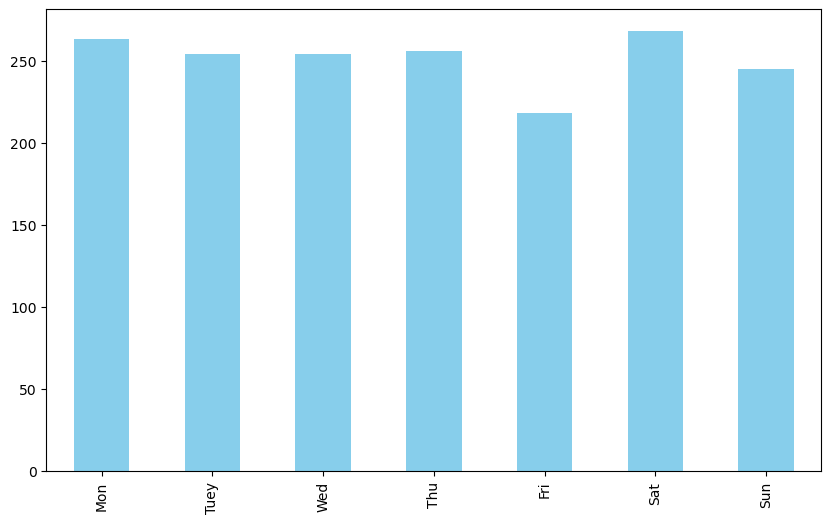

In [23]:
# Q19: calculate and plot the number of observations each day of the week has
dt = pd.read_csv('data/summer-travel-gps-full.csv', index_col='date', parse_dates=True)
dt = dt[~dt.index.duplicated()]

weekday_counts = dt.index.weekday.value_counts().sort_index()
weekday_counts.index = ['Mon', 'Tuey', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

plt.figure(figsize=(10, 6)) 
weekday_counts.plot(kind='bar', color='skyblue')